# Trigonometric Functions — Lecture 7
## Quick Recap · Two Hard Questions · Multiple Angles: $\sin 2\theta$

**Source:** [Trigonometric Functions 07 | Quick Recap | Sin (2θ)](https://www.youtube.com/watch?v=hQ5B04DF4YU&list=PLF_7kfnwLFCGWE2w0BsarSM9mbBJMrdRL&index=7), Physics Wallah (Class 11 / IIT JEE, PACE series), about 45 min

**Prerequisites:** Lectures 4–6 (expansion, product-to-sum, C & D formulae).

### What this lecture covers
1. **Quick recap** of every formula so far, plus the special values at $15^\circ$ and $75^\circ$
2. **Hard question 1** (componendo–dividendo): if $\frac{\tan(\theta+x)}{a} = \frac{\tan(\theta+y)}{b} = \frac{\tan(\theta+z)}{c}$, then $\sum\frac{a+b}{a-b}\sin^2(x-y) = 0$
3. **Hard question 2** (power reduction): if $\sin\theta + \sin^2\theta = 1$, evaluate $\cos^{12}\theta + 3\cos^{10}\theta + 3\cos^8\theta + \cos^6\theta$
4. Homework: $\cos^2 73^\circ + \cos^2 47^\circ + \cos 73^\circ\cos 47^\circ$
5. **Multiple and sub-multiple angles**, starting with $\sin 2\theta = 2\sin\theta\cos\theta$ and its "masala" form

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Arc, Circle, Polygon

# Same look as the earlier lectures
BLUE, ORANGE, AQUA, VIOLET = "#2a78d6", "#eb6834", "#1baf7a", "#4a3aa7"
INK, INK2, GRID = "#0b0b0b", "#52514e", "#e4e3df"
plt.rcParams.update({
    "figure.dpi": 110, "axes.edgecolor": INK2, "axes.labelcolor": INK,
    "text.color": INK, "xtick.color": INK2, "ytick.color": INK2,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 10,
})
d = np.deg2rad
rng = np.random.default_rng(7)

def verify(name, lhs, rhs):
    ok = np.isfinite(lhs) & np.isfinite(rhs) & (np.abs(lhs) < 1e6)
    good = np.isclose(lhs[ok], rhs[ok], rtol=1e-6, atol=1e-9)
    print(f"{name}:  {good.mean()*100:.2f}% of {ok.sum():,} samples agree "
          f"(max |LHS − RHS| = {np.max(np.abs(lhs[ok] - rhs[ok])):.1e})")
print("ready")

ready


---
## 1. Quick Recap

**Expansion formulae**
| | $A + B$ | $A - B$ |
|---|---|---|
| $\sin$ | $\sin A\cos B + \cos A\sin B$ | $\sin A\cos B - \cos A\sin B$ |
| $\cos$ | $\cos A\cos B - \sin A\sin B$ | $\cos A\cos B + \sin A\sin B$ |
| $\tan$ | $\dfrac{\tan A + \tan B}{1 - \tan A\tan B}$ | $\dfrac{\tan A - \tan B}{1 + \tan A\tan B}$ |
| $\cot$ | $\dfrac{\cot A\cot B - 1}{\cot B + \cot A}$ | $\dfrac{\cot A\cot B + 1}{\cot B - \cot A}$ |

**Product-to-sum**
$2\sin A\cos B = \sin(A+B) + \sin(A-B)$,
$2\cos A\sin B = \sin(A+B) - \sin(A-B)$,
$2\cos A\cos B = \cos(A+B) + \cos(A-B)$,
$2\sin A\sin B = \cos(A-B) - \cos(A+B)$

**Sum-to-product (C & D)**
$\sin C + \sin D = 2\sin\frac{C+D}{2}\cos\frac{C-D}{2}$,
$\sin C - \sin D = 2\cos\frac{C+D}{2}\sin\frac{C-D}{2}$,
$\cos C + \cos D = 2\cos\frac{C+D}{2}\cos\frac{C-D}{2}$,
$\cos C - \cos D = -2\sin\frac{C+D}{2}\sin\frac{C-D}{2}$

> The lecturer's rule: **don't continue until every formula is memorised.** Revise first, then move on.

### 1.1 Special values at $15^\circ$ and $75^\circ$ (memorise these for JEE)
From $\sin 15^\circ = \sin(45^\circ - 30^\circ)$ and $\cos 15^\circ = \cos(45^\circ - 30^\circ)$:

$$\sin 15^\circ = \cos 75^\circ = \frac{\sqrt3 - 1}{2\sqrt2}, \qquad \cos 15^\circ = \sin 75^\circ = \frac{\sqrt3 + 1}{2\sqrt2}$$

Dividing them and rationalising (multiply by $\sqrt3 - 1$ or $\sqrt3 + 1$):

$$\tan 15^\circ = \cot 75^\circ = \frac{\sqrt3 - 1}{\sqrt3 + 1} = 2 - \sqrt3, \qquad \cot 15^\circ = \tan 75^\circ = 2 + \sqrt3$$

In [2]:
r2, r3 = np.sqrt(2), np.sqrt(3)
table = [("sin 15° = cos 75°", np.sin(d(15)), (r3 - 1)/(2*r2), "(√3 − 1)/(2√2)"),
         ("cos 15° = sin 75°", np.cos(d(15)), (r3 + 1)/(2*r2), "(√3 + 1)/(2√2)"),
         ("tan 15° = cot 75°", np.tan(d(15)), 2 - r3, "2 − √3"),
         ("cot 15° = tan 75°", 1/np.tan(d(15)), 2 + r3, "2 + √3")]
for name, v, exact, form in table:
    print(f"{name:<20} = {v:.6f}    {form:<15} = {exact:.6f}   {'✓' if np.isclose(v, exact) else '✗'}")

sin 15° = cos 75°    = 0.258819    (√3 − 1)/(2√2)  = 0.258819   ✓
cos 15° = sin 75°    = 0.965926    (√3 + 1)/(2√2)  = 0.965926   ✓
tan 15° = cot 75°    = 0.267949    2 − √3          = 0.267949   ✓
cot 15° = tan 75°    = 3.732051    2 + √3          = 3.732051   ✓


---
## 2. Hard Question 1: Componendo–Dividendo

> If $\dfrac{\tan(\theta + x)}{a} = \dfrac{\tan(\theta + y)}{b} = \dfrac{\tan(\theta + z)}{c}$, prove
> $$\frac{a+b}{a-b}\sin^2(x-y) + \frac{b+c}{b-c}\sin^2(y-z) + \frac{c+a}{c-a}\sin^2(z-x) = 0$$

### Tool: componendo and dividendo (from the Ratio & Proportion chapter)
$$\frac{a}{b} = \frac{c}{d} \quad\Longrightarrow\quad \frac{a + b}{a - b} = \frac{c + d}{c - d}$$
("Add over subtract" on both sides.)

### Step 1: one pair at a time
From the first two ratios:
$$\frac{\tan(\theta+x)}{\tan(\theta+y)} = \frac{a}{b}$$
Apply componendo–dividendo:
$$\frac{\tan(\theta+x) + \tan(\theta+y)}{\tan(\theta+x) - \tan(\theta+y)} = \frac{a+b}{a-b}$$

### Step 2: convert to sines and cosines
Write $\tan = \frac{\sin}{\cos}$ and take the LCM. The common $\cos(\theta+x)\cos(\theta+y)$ cancels:
$$\frac{\sin(\theta+x)\cos(\theta+y) + \cos(\theta+x)\sin(\theta+y)}{\sin(\theta+x)\cos(\theta+y) - \cos(\theta+x)\sin(\theta+y)} = \frac{\sin(2\theta + x + y)}{\sin(x - y)} = \frac{a+b}{a-b}$$
The numerator is the $\sin(A+B)$ expansion and the denominator is $\sin(A-B)$.

### Step 3: build the required term
Multiply both sides by $\sin^2(x - y)$:
$$\frac{a+b}{a-b}\sin^2(x-y) = \sin(2\theta + x + y)\sin(x - y)$$
Multiply and divide by 2 so the product-to-sum formula applies:
$$= \frac12\Big[2\sin(2\theta+x+y)\sin(x-y)\Big] = \frac12\Big[\cos(2\theta + 2y) - \cos(2\theta + 2x)\Big]$$

### Step 4: cyclic copies, then add
In the same way:
$$\frac{b+c}{b-c}\sin^2(y-z) = \frac12\Big[\cos(2\theta+2z) - \cos(2\theta+2y)\Big]$$
$$\frac{c+a}{c-a}\sin^2(z-x) = \frac12\Big[\cos(2\theta+2x) - \cos(2\theta+2z)\Big]$$

Adding all three, every cosine appears once with $+$ and once with $-$:
$$\text{LHS} = 0 \quad\blacksquare$$

Hard Q1  sum of the three terms = 0:  100.00% of 50,000 samples agree (max |LHS − RHS| = 6.4e-16)


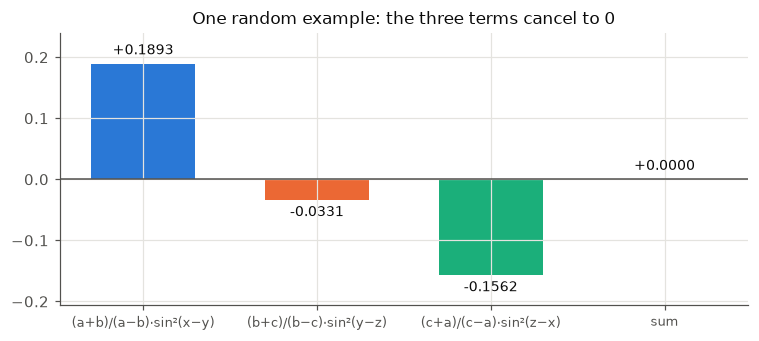

In [3]:
# Numerical check: pick θ, x, y, z at random, then choose a, b, c so the given ratios are equal (common value k)
n = 50_000
th, x, y, z = rng.uniform(-0.6, 0.6, (4, n))
k = rng.uniform(0.5, 2.0, n)
a, b, c = np.tan(th + x)/k, np.tan(th + y)/k, np.tan(th + z)/k
t1 = (a + b)/(a - b)*np.sin(x - y)**2
t2 = (b + c)/(b - c)*np.sin(y - z)**2
t3 = (c + a)/(c - a)*np.sin(z - x)**2
verify("Hard Q1  sum of the three terms = 0", t1 + t2 + t3, np.zeros(n))

# One example, drawn: the three terms cancel
i = 3
fig, ax = plt.subplots(figsize=(7, 3.2))
vals = [t1[i], t2[i], t3[i], t1[i] + t2[i] + t3[i]]
cols = [BLUE, ORANGE, AQUA, INK]
ax.bar(range(4), vals, color=cols, width=0.6)
ax.axhline(0, color=INK2, lw=1); ax.set_ylim(min(vals) - 0.05, max(vals) + 0.05)
for j, v in enumerate(vals):
    ax.text(j, v + (0.01 if v >= 0 else -0.01), f"{v:+.4f}", ha="center", va="bottom" if v >= 0 else "top", fontsize=9)
ax.set_xticks(range(4), ["(a+b)/(a−b)·sin²(x−y)", "(b+c)/(b−c)·sin²(y−z)", "(c+a)/(c−a)·sin²(z−x)", "sum"], fontsize=8.5)
ax.set_title("One random example: the three terms cancel to 0", fontsize=11)
plt.tight_layout(); plt.show()

---
## 3. Hard Question 2: Shrinking the Powers

> If $\sin\theta + \sin^2\theta = 1$, evaluate $\cos^{12}\theta + 3\cos^{10}\theta + 3\cos^8\theta + \cos^6\theta$ (and the related expression from the lecture).

### The key substitution
$$\sin\theta = 1 - \sin^2\theta = \cos^2\theta$$
So **$\cos^2\theta = \sin\theta$**, and every even power of $\cos$ becomes a power of $\sin$:
$$\cos^{12}\theta = (\cos^2\theta)^6 = \sin^6\theta, \quad \cos^{10}\theta = \sin^5\theta, \quad \cos^8\theta = \sin^4\theta, \quad \cos^6\theta = \sin^3\theta$$

### The lecture's method: keep reducing the powers
The lecturer's strategy is to **make the big powers small**: repeatedly write $\sin^2\theta = 1 - \cos^2\theta$ and $\cos^2\theta = \sin\theta$, expand with the $(a-b)^3$ and $(a-b)^2$ identities, and cancel. The powers fall $12, 10, 8 \to 3, 2 \to 1$, until everything is in terms of $\sin\theta + \sin^2\theta$, which equals $1$.

### A shortcut *(extra: same answer, fewer steps)*
$$\sin^6\theta + 3\sin^5\theta + 3\sin^4\theta + \sin^3\theta = \sin^3\theta\,(\sin^3\theta + 3\sin^2\theta + 3\sin\theta + 1) = \sin^3\theta(1 + \sin\theta)^3$$
$$= \big(\sin\theta + \sin^2\theta\big)^3 = 1^3 = \boxed{1}$$

> **Correction from Lecture 8:** in class the working ended with "$4 - 2 = 2$", but at the start of the next lecture the lecturer says he forgot to subtract a final $1$ in a hurry, so **the correct answer is $1$**. That matches the shortcut above. He also praised a student's solution that spotted $(\sin\theta + \sin^2\theta)^3$ directly.

### Bonus: what is $\sin\theta$ here? *(extra)*
$s^2 + s - 1 = 0$ gives $s = \dfrac{\sqrt5 - 1}{2} \approx 0.618$, the reciprocal of the **golden ratio** $\varphi$. So $\sin\theta = 1/\varphi$ and $\theta \approx 38.17^\circ$.

sinθ = 0.618034  (1/φ),  θ = 38.1727°
check sinθ + sin²θ = 1.000000000000
check cos²θ = sinθ:  0.618033988750 vs 0.618033988750
cos¹²θ + 3cos¹⁰θ + 3cos⁸θ + cos⁶θ = 1.000000000000


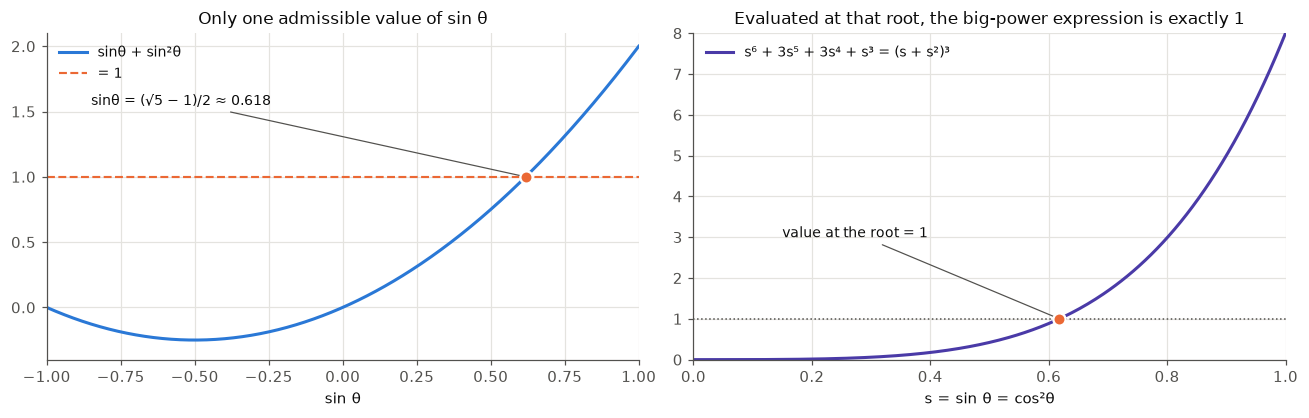

In [4]:
s0 = (np.sqrt(5) - 1)/2                       # the only valid root (the other is < −1)
theta0 = np.arcsin(s0); c2 = np.cos(theta0)**2
print(f"sinθ = {s0:.6f}  (1/φ),  θ = {np.rad2deg(theta0):.4f}°")
print(f"check sinθ + sin²θ = {s0 + s0**2:.12f}")
print(f"check cos²θ = sinθ:  {c2:.12f} vs {s0:.12f}")
expr = c2**6 + 3*c2**5 + 3*c2**4 + c2**3
print(f"cos¹²θ + 3cos¹⁰θ + 3cos⁸θ + cos⁶θ = {expr:.12f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 3.9))
s = np.linspace(-1, 1, 600)
ax = axes[0]
ax.plot(s, s + s**2, color=BLUE, lw=2, label="sinθ + sin²θ")
ax.axhline(1, color=ORANGE, lw=1.4, ls="--", label="= 1")
ax.plot(s0, 1, "o", color=ORANGE, ms=8, mec="white", mew=1.5, zorder=5)
ax.annotate(f"sinθ = (√5 − 1)/2 ≈ {s0:.3f}", (s0, 1), xytext=(-0.85, 1.55), fontsize=9,
            arrowprops=dict(arrowstyle="-", color=INK2, lw=0.8))
ax.set_xlabel("sin θ"); ax.set_xlim(-1, 1); ax.set_ylim(-0.4, 2.1)
ax.legend(frameon=False, loc="upper left", fontsize=9)
ax.set_title("Only one admissible value of sin θ", fontsize=11)

ax = axes[1]
P = s**6 + 3*s**5 + 3*s**4 + s**3                 # the expression with cos²θ replaced by s = sinθ
ax.plot(s[s > 0], P[s > 0], color=VIOLET, lw=2, label="s⁶ + 3s⁵ + 3s⁴ + s³ = (s + s²)³")
ax.axhline(1, color=INK2, lw=1, ls=":")
ax.plot(s0, 1, "o", color=ORANGE, ms=8, mec="white", mew=1.5, zorder=5)
ax.annotate("value at the root = 1", (s0, 1), xytext=(0.15, 3.0), fontsize=9,
            arrowprops=dict(arrowstyle="-", color=INK2, lw=0.8))
ax.set_xlabel("s = sin θ = cos²θ"); ax.set_xlim(0, 1); ax.set_ylim(0, 8)
ax.legend(frameon=False, loc="upper left", fontsize=9)
ax.set_title("Evaluated at that root, the big-power expression is exactly 1", fontsize=11)
plt.tight_layout(); plt.show()

---
## 4. Homework from the Lecture

> Find the value of $\cos^2 73^\circ + \cos^2 47^\circ + \cos 73^\circ\cos 47^\circ$.
> (The lecturer says it has a neat numerical answer and will discuss it next time.)

<details>
<summary>Hint / answer (open after attempting)</summary>

Let $A = 73^\circ$ and $B = 47^\circ$, so $A + B = 120^\circ$ and $A - B = 26^\circ$.

- $\cos^2A + \cos^2B = 1 + \cos^2A - \sin^2B = 1 + \cos(A+B)\cos(A-B)$, using the Lecture 5 result. That equals $1 - \frac12\cos 26^\circ$.
- $\cos A\cos B = \frac12[\cos(A+B) + \cos(A-B)] = -\frac14 + \frac12\cos 26^\circ$

Adding them, the $\cos 26^\circ$ terms cancel:
$$1 - \tfrac14 = \boxed{\tfrac34}$$
</details>

In [5]:
c = lambda deg: np.cos(d(deg))
print(f"cos²73° + cos²47° + cos73°·cos47° = {c(73)**2 + c(47)**2 + c(73)*c(47):.12f}   (3/4 = 0.75)")

cos²73° + cos²47° + cos73°·cos47° = 0.750000000000   (3/4 = 0.75)


---
## 5. Multiple and Sub-multiple Angles

Starting from an angle $\theta$:
- **Multiple angles:** multiply it, giving $2\theta, 3\theta, 4\theta, \dots$
- **Sub-multiple angles:** divide it, giving $\dfrac{\theta}{2}, \dfrac{\theta}{3}, \dfrac{\theta}{4}, \dots$

**The lecturer's claim:** master the formulas for $2\theta$, $3\theta$ and $\frac{\theta}{2}$, and you can derive everything else ($4\theta$, $\frac{\theta}{3}$, …) yourself. The $2\theta$ family comes first, starting with $\sin$ (the "papa" function).

### 5.1 Deriving $\sin 2\theta$
$$\sin(A + B) = \sin A\cos B + \cos A\sin B$$
This holds for **every** $A$ and $B$, so we may put $A = B = \theta$:
$$\sin 2\theta = \sin\theta\cos\theta + \cos\theta\sin\theta$$
One mango plus one mango is two mangoes:
$$\boxed{\sin 2\theta = 2\sin\theta\cos\theta}$$

### 5.2 The "masala" form
Look at what happened to the angle: inside $\sin$ it was $2\theta$, and on the right it is **half of that**, $\theta$. So for **any** expression ("masala") inside:
$$\boxed{\sin(\text{masala}) = 2\sin\frac{\text{masala}}{2}\cos\frac{\text{masala}}{2}}$$

Examples:
$$\sin 4\theta = 2\sin 2\theta\cos 2\theta, \qquad \sin 3\theta = 2\sin\frac{3\theta}{2}\cos\frac{3\theta}{2}, \qquad \sin\theta = 2\sin\frac{\theta}{2}\cos\frac{\theta}{2}$$

The last one, $\sin\theta = 2\sin\frac{\theta}{2}\cos\frac{\theta}{2}$, is already a **sub-multiple** angle formula.

In [6]:
x = rng.uniform(-10, 10, 100_000)
verify("sin 2θ = 2 sinθ cosθ", np.sin(2*x), 2*np.sin(x)*np.cos(x))
verify("sin θ  = 2 sin(θ/2) cos(θ/2)", np.sin(x), 2*np.sin(x/2)*np.cos(x/2))
verify("sin 4θ = 2 sin2θ cos2θ", np.sin(4*x), 2*np.sin(2*x)*np.cos(2*x))
verify("sin 3θ = 2 sin(3θ/2) cos(3θ/2)", np.sin(3*x), 2*np.sin(1.5*x)*np.cos(1.5*x))

sin 2θ = 2 sinθ cosθ:  100.00% of 100,000 samples agree (max |LHS − RHS| = 2.2e-16)


sin θ  = 2 sin(θ/2) cos(θ/2):  100.00% of 100,000 samples agree (max |LHS − RHS| = 2.2e-16)
sin 4θ = 2 sin2θ cos2θ:  100.00% of 100,000 samples agree (max |LHS − RHS| = 2.2e-16)
sin 3θ = 2 sin(3θ/2) cos(3θ/2):  100.00% of 100,000 samples agree (max |LHS − RHS| = 2.2e-16)


### 5.3 A picture of $\sin 2\theta = 2\sin\theta\cos\theta$ *(extra: area proof)*
Take an isosceles triangle with two sides of length $1$ and the angle $2\theta$ between them. Compute its area in two ways:
- **Two sides and the included angle:** $\text{Area} = \frac12\cdot 1\cdot 1\cdot\sin 2\theta$
- **Split it down the middle** into two right triangles, each with hypotenuse $1$, legs $\cos\theta$ and $\sin\theta$, and area $\frac12\sin\theta\cos\theta$. So $\text{Area} = \sin\theta\cos\theta$.

Equating the two: $\frac12\sin 2\theta = \sin\theta\cos\theta$, i.e. $\sin 2\theta = 2\sin\theta\cos\theta$.

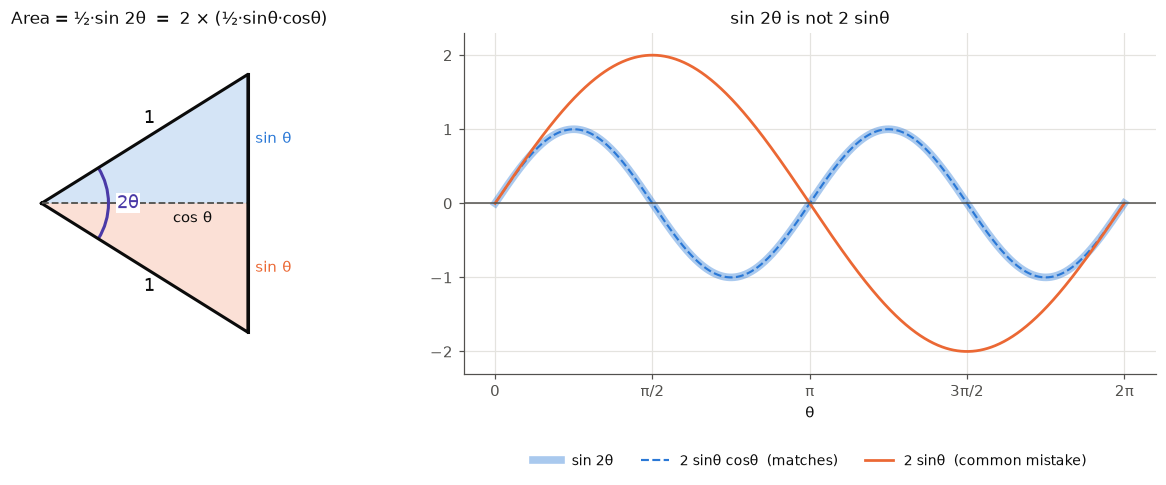

In [7]:
th = d(32)
O = np.array([0, 0]); P1 = np.array([np.cos(th), np.sin(th)]); P2 = np.array([np.cos(th), -np.sin(th)])
M = np.array([np.cos(th), 0])
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), gridspec_kw={"width_ratios": [1, 1.25]})

ax = axes[0]; ax.set_aspect("equal"); ax.axis("off")
ax.add_patch(Polygon([O, P1, M], closed=True, fc=BLUE + "33", ec="none"))
ax.add_patch(Polygon([O, M, P2], closed=True, fc=ORANGE + "33", ec="none"))
ax.plot(*zip(O, P1, P2, O), color=INK, lw=2)
ax.plot(*zip(O, M), color=INK2, lw=1.2, ls="--"); ax.plot(*zip(P1, P2), color=INK, lw=2)
ax.add_patch(Arc(O, 0.55, 0.55, theta1=-np.rad2deg(th), theta2=np.rad2deg(th), color=VIOLET, lw=2))
ax.text(0.31, 0.0, "2θ", color=VIOLET, fontsize=12, va="center", bbox=dict(fc="white", ec="none", pad=0.5))
ax.text(0.42, 0.33, "1", fontsize=12); ax.text(0.42, -0.36, "1", fontsize=12)
ax.text(np.cos(th) + 0.03, np.sin(th)/2, "sin θ", color=BLUE, fontsize=10, va="center")
ax.text(np.cos(th) + 0.03, -np.sin(th)/2, "sin θ", color=ORANGE, fontsize=10, va="center")
ax.text(0.62, -0.03, "cos θ", fontsize=10, ha="center", va="top")
ax.set_xlim(-0.1, 1.15); ax.set_ylim(-0.7, 0.7)
ax.set_title("Area = ½·sin 2θ  =  2 × (½·sinθ·cosθ)", fontsize=11)

ax = axes[1]
t = np.linspace(0, 2*np.pi, 1000)
ax.plot(t, np.sin(2*t), color=BLUE, lw=5, alpha=0.4, label="sin 2θ")
ax.plot(t, 2*np.sin(t)*np.cos(t), color=BLUE, lw=1.4, ls="--", label="2 sinθ cosθ  (matches)")
ax.plot(t, 2*np.sin(t), color=ORANGE, lw=1.8, label="2 sinθ  (common mistake)")
ax.axhline(0, color=INK2, lw=1)
ax.set_xticks(np.arange(0, 2.01, 0.5)*np.pi, ["0", "π/2", "π", "3π/2", "2π"]); ax.set_xlabel("θ")
ax.set_ylim(-2.3, 2.3)
ax.legend(frameon=False, ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.2), fontsize=9)
ax.set_title("sin 2θ is not 2 sinθ", fontsize=11)
plt.tight_layout(); plt.show()

---
## 6. Summary

- **Special values:** $\sin 15^\circ = \cos 75^\circ = \frac{\sqrt3-1}{2\sqrt2}$, $\cos 15^\circ = \sin 75^\circ = \frac{\sqrt3+1}{2\sqrt2}$, $\tan 15^\circ = 2 - \sqrt3$, $\tan 75^\circ = 2 + \sqrt3$
- **Componendo–dividendo:** $\frac{a}{b} = \frac{c}{d} \Rightarrow \frac{a+b}{a-b} = \frac{c+d}{c-d}$. Combined with $\tan\to\frac{\sin}{\cos}$, a sum of tangents over their difference becomes $\frac{\sin(\text{sum})}{\sin(\text{difference})}$.
- **Power reduction:** if a condition gives $\cos^2\theta = \sin\theta$ (or similar), substitute repeatedly until the powers are small and the condition can be reused.
- **Multiple and sub-multiple angles:** $2\theta, 3\theta, \dots$ and $\frac{\theta}{2}, \frac{\theta}{3}, \dots$
- $\sin 2\theta = 2\sin\theta\cos\theta$, and in general $\sin(\text{masala}) = 2\sin\frac{\text{masala}}{2}\cos\frac{\text{masala}}{2}$

**Next lecture:** more of the $2\theta$ family ($\cos 2\theta$, $\tan 2\theta$, …).

### Practice
1. Express $\sin 6x$ and $\sin\frac{x}{2}$ using the masala form.
2. Find $\sin 2\theta$ if $\sin\theta = \frac35$ and $\theta$ is in quadrant II.
3. Prove $\sin\theta\cos\theta\cos 2\theta\cos 4\theta = \frac18\sin 8\theta$. *(Hint: use the masala form three times.)*

In [8]:
# Practice answers
s, c = 3/5, -4/5                                   # quadrant II: sin > 0, cos < 0
print(f"2. sin2θ = 2·(3/5)·(−4/5) = {2*s*c} (= −24/25)")
x = rng.uniform(-3, 3, 50_000)
verify("3. sinθ cosθ cos2θ cos4θ = ⅛ sin8θ", np.sin(x)*np.cos(x)*np.cos(2*x)*np.cos(4*x), np.sin(8*x)/8)

2. sin2θ = 2·(3/5)·(−4/5) = -0.96 (= −24/25)
3. sinθ cosθ cos2θ cos4θ = ⅛ sin8θ:  100.00% of 50,000 samples agree (max |LHS − RHS| = 5.6e-17)
